In [ ]:
import pythia8
import numpy as np

# ---------- small helpers ----------
def dot(a, b):  # (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]
def phimod(px, py): return float(np.arctan2(py, px))
def is_hadron(pid): return abs(pid) >= 100

zh_min    = 0.20
xL_min    = 0.20
t_abs_max = 1.0        # was 2.0  (cleaner forward tag sample)
r_max     = 0.25      # << NEW: q_T / Q cut

# ---- Coarse binning helpers for mixed-event matching ----
def bin_x(v):    return int(np.clip(np.floor((v - 0.03)/0.005), 0, 20))   # tuned to your x-window
def bin_Q(v):    return int(np.clip(np.floor((v - 40.0)/5.0),     0, 12)) # 5 GeV bins
def bin_xL(v):   return int(np.clip(np.floor(v/0.05),             0, 20)) # 0.05-wide bins
def bin_t(v):    return int(np.clip(np.floor(abs(v)/0.2),         0, 20)) # 0.2 GeV^2 bins

In [ ]:
# ============================ Pythia setup ============================
pythia = pythia8.Pythia()
pythia.readString("Beams:idA = 2212")
pythia.readString("Beams:idB = 11")
#pythia.readString("Beams:eA = 275.0"); pythia.readString("Beams:eB = 18.00")
pythia.readString("Beams:eA = 920.0")
pythia.readString("Beams:eB = 28.00")
pythia.readString("Beams:frameType = 2")
pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("HardQCD:all = on")
pythia.readString("PDF:lepton = off")
pythia.readString("ColourReconnection:reconnect = on")   # toggle to probe color-flow
pythia.readString("PhaseSpace:Q2Min = 2025.0")
#pythia.readString("PhaseSpace:Q2Max = 3025.0")
pythia.init()

# Kinematic windows
Qmin, Qmax = 45.0, 55.0
xmin, xmax = 0.10, 0.99

# Accumulators
qT_same = []
cos_dphi_same = []
xL_list, t_list, Q_list = [], [], []

# Mixed-event pools
# store vectors + labels so we can match (x,Q,xL,t) in mixed
curr_pool = []   # (PhT_vec, zh, bX, bQ, bXL, bT)
targ_pool = []   # (PLT_vec, xL, t,  bX, bQ, bXL, bT)

# Diagnostics
n_pass_evt = n_pass_transform = 0
n_have_curr = n_have_targ = 0
n_pass_zhxL = n_pass_qT = 0

n_events = 1000000

# ============================ Event loop =============================
for iEvent in range(n_events):
    if not pythia.next():
        continue

    ev = pythia.event

    # Identify beam/scattered leptons and incoming proton
    e_in = e_sc = p_in = None
    for p in ev:
        if p.id() == 11 and p.status() == -12: e_in = p
        elif p.id() == 11 and p.status() == 44: e_sc = p
        elif p.id() == 2212 and p.status() < 0: p_in = p
    if not (e_in and e_sc and p_in): continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon (lab)
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0: continue
    Q  = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))
    phiq = float(np.arctan2(q2, q1))
    S = 4.0*Ee*Ep

    k_l_in = np.array([Ee, 0.0, 0.0, -Ee])
    p_p_in = np.array([Ep, 0.0, 0.0,  Ep])

    p_dot_q = dot(p_p_in, qmu)
    if p_dot_q == 0.0: continue
    x = Q2 / (2.0 * p_dot_q)
    if x <= 0.0: continue
    y = Q2 / (S * x)

    if not (Qmin <= Q <= Qmax): continue
    if not (xmin <= x <= xmax): continue
    n_pass_evt += 1

    # ------------------- Breit-like transform matrices ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0.0, 0.0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0.0, 0.0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])
    M0 = np.array([
        [1, 0, 0, 0],
        [0,  np.cos(phiq),  np.sin(phiq), 0],
        [0, -np.sin(phiq),  np.cos(phiq), 0],
        [0, 0, 0, 1]
    ])

    denom_M1 = 2.0 * y * np.sqrt(S * (-qT**2 + S * (1.0 + x) * y))
    if denom_M1 == 0.0: continue
    M1 = np.array([
        [(-qT**2 + S*y*(1.0 + x + y)) / denom_M1, 0, 0, ( qT**2 + S*y*(-1.0 - x + y)) / denom_M1],
        [0, 1., 0, 0],
        [0, 0, 1., 0],
        [( qT**2 + S*y*(-1.0 - x + y)) / denom_M1, 0, 0, (-qT**2 + S*y*(1.0 + x + y)) / denom_M1]
    ])

    den2 = (-qT**2 + S*(1.0 + x)*y)
    if den2 <= 0.0: continue
    denom_M2_s1 = np.sqrt(S * (1.0 + x) * y / den2)
    denom_M2_s2 = np.sqrt(S * (1.0 + x) * y)
    if denom_M2_s1 == 0.0 or denom_M2_s2 == 0.0: continue
    M2 = np.array([
        [1, 0, 0, 0],
        [0, 1.0/denom_M2_s1, 0, qT/denom_M2_s2],
        [0, 0, 1, 0],
        [0, -qT/denom_M2_s2, 0, 1.0/denom_M2_s1]
    ])

    denom_M3_sqrt = np.sqrt(den2)
    numer_M3_log = qT + np.sqrt(S * (1.0 + x) * y)
    denom_M3_log = -qT + np.sqrt(S * (1.0 + x) * y)
    if denom_M3_log <= 0.0 or numer_M3_log <= 0.0: continue
    cosh_arg = numer_M3_log / denom_M3_log
    M3 = np.array([
        [np.cosh(0.5 * np.log(cosh_arg)), -qT / denom_M3_sqrt, 0, 0],
        [-qT / denom_M3_sqrt, np.cosh(0.5 * np.log(cosh_arg)), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    if x*(1.0 + x) <= 0.0: continue
    denom_M4 = 2.0 * np.sqrt(x * (1.0 + x))
    M4 = np.array([
        [(1.0 + 2.0*x) / denom_M4, 0, 0, 1.0/denom_M4],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [1.0/denom_M4, 0, 0, (1.0 + 2.0*x) / denom_M4]
    ])

    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1

    def apply_LT(E, px, py, pz):
        v = LT @ np.array([E, px, py, pz])
        return np.array([v[0], v[1], v[2], v[3]])  # (E', px', py', pz')

    # ---------------- Collect finals & transform stepwise --------------
    finals = []  # (lab4, trf4, pid)
    for p in ev:
        if not p.isFinal(): continue
        if abs(p.id()) == 11: continue  # drop leptons
        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = apply_LT(*lab)
        finals.append((lab, trf, p.id()))
    if not finals: continue
    n_pass_transform += 1

    # ------------------ Tag current & target (hadron-only) -------------
    # Current/backward (Breit): pick hadron with max pT' and pz' < 0
    curr_cand = None; best_pt2_curr = -1.0
    for lab, trf, pid in finals:
        if not is_hadron(pid): continue
        E, px, py, pz = trf
        if pz >= 0.0: continue
        pT2 = px*px + py*py
        if pT2 > best_pt2_curr:
            best_pt2_curr = pT2
            curr_cand = (lab, trf, pid)

    # Target/forward (Breit): pick hadron with max E' and pz' > 0
    targ_cand = None; best_E_targ = -1.0
    for lab, trf, pid in finals:
        if not is_hadron(pid): continue
        E, px, py, pz = trf
        if pz <= 0.0: continue
        if E > best_E_targ:
            best_E_targ = E
            targ_cand = (lab, trf, pid)

    if curr_cand is None or targ_cand is None:
        continue
    n_have_curr += 1
    n_have_targ += 1

    lab_h, trf_h, _ = curr_cand
    lab_L, trf_L, _ = targ_cand

    # --------------------- Compute z_h, x_L, t (lab) ------------------
    zh  = dot(p_p_in, lab_h) / p_dot_q
    xL  = lab_L[0] / Ep if Ep > 0 else 0.0
    t4  = p_p_in - lab_L
    tval = dot(t4, t4)

    # --- NEW: acceptance cuts to tame 1/zh and 1/xL and focus on leading forward ---
    if (zh <= zh_min) or (xL <= xL_min):
        continue
    if abs(tval) > t_abs_max:
        continue
    n_pass_zhxL += 1

#    # after you set PhT, PLT from the transformed 4-vectors
#    if np.linalg.norm(PhT) > PhT_max or np.linalg.norm(PLT) > PLT_max:
#        continue

    # --------------------- Build qT imbalance (Breit) ------------------
    Eh, pxh, pyh, pzh = trf_h
    EL, pxL, pyL, pzL = trf_L
    PhT = np.array([pxh, pyh])
    PLT = np.array([pxL, pyL])

    khT = PhT/zh
    kLT = PLT/xL

    qT_vec = khT + kLT
    qTmag  = float(np.linalg.norm(qT_vec))

    print(qTmag/Q)

    # NEW: cap tag pT in Breit frame to stay in TMD-ish region
    if qTmag/Q > r_max:
        continue

    dphi = (phimod(pxh, pyh) - phimod(pxL, pyL) + np.pi) % (2*np.pi) - np.pi
    cos_dphi = float(np.cos(dphi))

    # TMD hygiene (start loose; tighten later if desired)
    if qTmag < Q:
        qT_same.append(qTmag)
        cos_dphi_same.append(cos_dphi)
        xL_list.append(float(xL))
        t_list.append(float(tval))
        Q_list.append(float(Q))
        n_pass_qT += 1

    # ----------------- Mixed-event pools with bin labels ----------------
    bX  = bin_x(x)
    bQ  = bin_Q(Q)
    bXL = bin_xL(xL)
    bT  = bin_t(tval)
    curr_pool.append((PhT.copy(), float(zh), bX, bQ, bXL, bT))
    targ_pool.append((PLT.copy(), float(xL), float(tval), bX, bQ, bXL, bT))

# ========================= Mixed-event baseline ======================
rng = np.random.default_rng(42)
n_mix = min(len(curr_pool), len(targ_pool))
qT_mix = []; cos_dphi_mix = []

if n_mix > 200:
    ci = rng.permutation(n_mix)
    ti = rng.permutation(n_mix)
    for i in range(n_mix):
        PhT, zh_i, bX_i, bQ_i, bXL_i, bT_i = curr_pool[ci[i]]
        PLT, xL_j, t_j,  bX_j, bQ_j, bXL_j, bT_j = targ_pool[ti[i]]

        # match (x, Q, xL, t) bins to make a fair baseline
        if (bX_i != bX_j) or (bQ_i != bQ_j) or (bXL_i != bXL_j) or (bT_i != bT_j):
            continue

        qTv  = PhT/zh_i + PLT/xL_j
        qTval = float(np.linalg.norm(qTv))

        dphi = (phimod(PhT[0], PhT[1]) - phimod(PLT[0], PLT[1]) + np.pi) % (2*np.pi) - np.pi
        cos_dphi_mix.append(float(np.cos(dphi)))
        qT_mix.append(qTval)

# ============================= Summaries =============================
def mean_std(arr):
    if len(arr) == 0: return (np.nan, np.nan)
    a = np.array(arr, dtype=float)
    return float(a.mean()), float(a.std(ddof=1)) if len(a) > 1 else (float(a.mean()), 0.0)

mqS, sqS = mean_std(qT_same)
mcS, scS = mean_std(cos_dphi_same)

print("\n=========== qT imbalance quick-look (Breit frame) ===========")
print(f"Same-event sample size: {len(qT_same)}")
print(f"<qT>_same = {mqS:.3f} GeV,  σ(qT)_same = {sqS:.3f} GeV")
print(f"<cosΔφ>_same = {mcS:.3f}  (back-to-back → -1)")

if len(qT_mix) > 50:
    mqM, sqM = mean_std(qT_mix)
    mcM, scM = mean_std(cos_dphi_mix)
    print("\nMixed-event baseline:")
    print(f"<qT>_mix  = {mqM:.3f} GeV,  σ(qT)_mix  = {sqM:.3f} GeV")
    print(f"<cosΔφ>_mix = {mcM:.3f}")
    print("\nConnected excess (same − mix):")
    print(f"Δ<qT>     = {mqS - mqM:+.3f} GeV")
    print(f"Δ<cosΔφ>  = {mcS - mcM:+.3f}")
else:
    print("\nMixed-event baseline not formed (need >200 pooled pairs).")

print("\n---- Selection diagnostics ----")
print(f"pass (x,Q):            {n_pass_evt}")
print(f"pass transform:        {n_pass_transform}")
print(f"have current tag:      {n_have_curr}")
print(f"have target tag:       {n_have_targ}")
print(f"pass zh/xL/|t| cuts:   {n_pass_zhxL}")
print(f"pass qT < Q:           {n_pass_qT}")

pythia.stat()



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 08 Oct 2025 at 00:47:55    |  | 
 |  |                                                                              |  | 
 |  |   Program docu


Saved plots: qT_dist.png, cosDeltaPhi_dist.png, qT_over_Q_dist.png


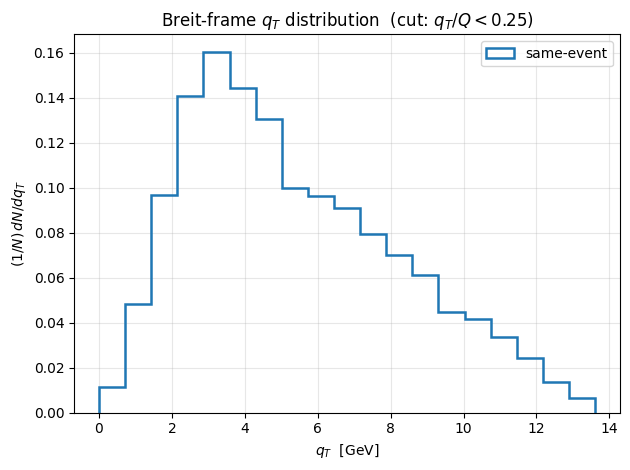

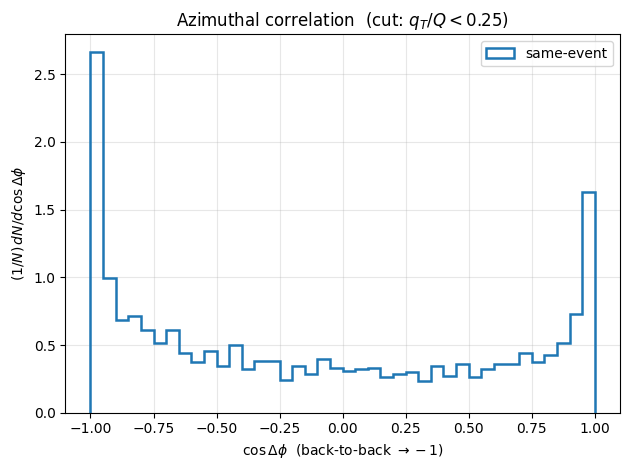

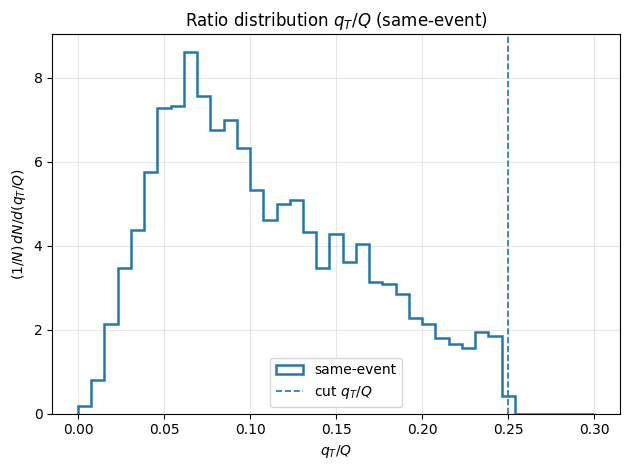

In [ ]:
# ============================== Plots ===============================
import matplotlib.pyplot as plt

def safe_max(lst, fallback=1.0):
    return float(np.max(lst)) if len(lst) else fallback

# 1) q_T distribution (same vs mixed)
qt_max = max(safe_max(qT_same, 1.0), safe_max(qT_mix, 1.0))
qt_max = min(qt_max, 20.0)  # keep x-axis reasonable
bins_qt = np.linspace(0.0, qt_max, 20)

plt.figure()
if len(qT_same):
    plt.hist(qT_same, bins=bins_qt, histtype='step', linewidth=1.8,
             density=True, label='same-event')
if len(qT_mix) > 50:
    plt.hist(qT_mix, bins=bins_qt, histtype='step', linewidth=1.2,
             density=True, label='mixed-event')
plt.xlabel(r'$q_T$  [GeV]')
plt.ylabel(r'$(1/N)\, dN/dq_T$')
plt.title('Breit-frame $q_T$ distribution' + (f'  (cut: $q_T/Q<{r_max:.2f}$)' if "r_max" in globals() else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qT_dist.png', dpi=180)

# 2) cos(Δφ) distribution (same vs mixed)
bins_phi = np.linspace(-1.0, 1.0, 41)
plt.figure()
if len(cos_dphi_same):
    plt.hist(cos_dphi_same, bins=bins_phi, histtype='step', linewidth=1.8,
             density=True, label='same-event')
if len(qT_mix) > 50:
    plt.hist(cos_dphi_mix, bins=bins_phi, histtype='step', linewidth=1.2,
             density=True, label='mixed-event')
plt.xlabel(r'$\cos\Delta\phi$  (back-to-back $\to -1$)')
plt.ylabel(r'$(1/N)\, dN/d\cos\Delta\phi$')
plt.title('Azimuthal correlation' + (f'  (cut: $q_T/Q<{r_max:.2f}$)' if "r_max" in globals() else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cosDeltaPhi_dist.png', dpi=180)

# 3) q_T / Q distribution (same-event only; mixed needs Q per pair)
if len(qT_same) and len(Q_list) == len(qT_same):
    r_vals = np.array(qT_same) / np.array(Q_list)
    r_max_plot = min(float(np.max(r_vals)), 1.0)
    bins_r = np.linspace(0.0, max(0.3, r_max_plot), 40)

    plt.figure()
    plt.hist(r_vals, bins=bins_r, histtype='step', linewidth=1.8,
             density=True, label='same-event')
    if "r_max" in globals():
        plt.axvline(r_max, linestyle='--', linewidth=1.2, label=r'cut $q_T/Q$')
    plt.xlabel(r'$q_T / Q$')
    plt.ylabel(r'$(1/N)\, dN/d(q_T/Q)$')
    plt.title(r'Ratio distribution $q_T/Q$ (same-event)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('qT_over_Q_dist.png', dpi=180)

print("\nSaved plots: qT_dist.png, cosDeltaPhi_dist.png, qT_over_Q_dist.png")


Saved: dsigma_d2qT.png


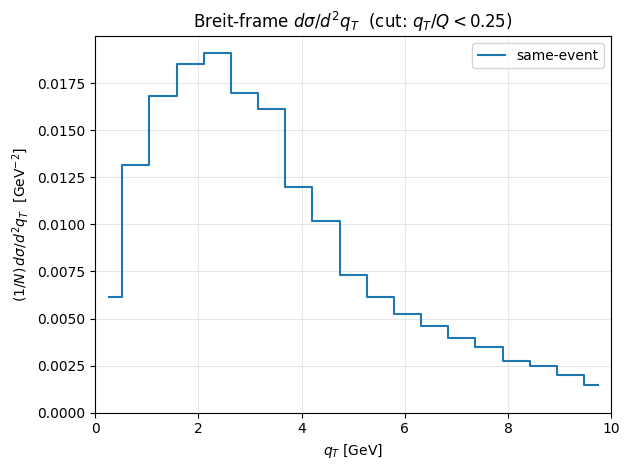

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- dσ/d²qT instead of qT dσ/d²qT ----------
bins_qt = np.linspace(0.0, 10.0, 20)
bin_centers = 0.5 * (bins_qt[1:] + bins_qt[:-1])
bin_widths = np.diff(bins_qt)

def dsig_d2qt(sample, label, color=None):
    counts, _ = np.histogram(sample, bins=bins_qt)
    norm = np.sum(counts * bin_widths)  # normalize to 1 if you like
    f = counts / (2*np.pi*bin_centers*bin_widths)  # divide by Jacobian
    plt.step(bin_centers, f / norm, where='mid', label=label, color=color)

plt.figure()
if len(qT_same):
    dsig_d2qt(qT_same, 'same-event')
if len(qT_mix) > 50:
    dsig_d2qt(qT_mix, 'mixed-event')

plt.xlabel(r'$q_T$ [GeV]')
plt.ylabel(r'$(1/N)\, d\sigma/d^2q_T$  [GeV$^{-2}$]')
plt.title(r'Breit-frame $d\sigma/d^2q_T$' + f'  (cut: $q_T/Q<{r_max:.2f}$)')
plt.xlim(0, 10)
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dsigma_d2qT.png', dpi=180)
print("Saved: dsigma_d2qT.png")
